In [26]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

import json

In [27]:
df = pd.read_csv("btc_daily_data.csv")

In [28]:
df.head()

,Date,Open,High,Low,Close,Volume
0,01-01-2012,4.58,4.84,4.58,4.84,10.000000
1,02-01-2012,4.84,5.00,4.84,5.00,10.100000
2,03-01-2012,5.00,5.32,5.00,5.29,107.085281
3,04-01-2012,5.29,5.57,4.93,5.57,107.233260
4,05-01-2012,5.57,6.46,5.57,6.42,70.328742


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5178 entries, 0 to 5177
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    5177 non-null   object 
 1   Open    5177 non-null   float64
 2   High    5177 non-null   float64
 3   Low     5177 non-null   float64
 4   Close   5177 non-null   float64
 5   Volume  5177 non-null   float64
dtypes: float64(5), object(1)
memory usage: 242.8+ KB


In [30]:
df = df.dropna()

In [31]:
# preparing features for the model
df['diff']=df['High']-df['Low']
df['volatility']=df['diff']/df['Low']
df['variance7']=df['volatility'].rolling(window=7).std()
df['variance15']=df['volatility'].rolling(window=15).std()
df['variance30']=df['volatility'].rolling(window=30).std()

df['price_change']=df['Close']-df['Open']

df['returns']=df['price_change']/df['Open']

df['Momentum1D']=df['Close']-df['Close'].shift(1)
df['Momentum7D']=df['Close']-df['Close'].shift(7)
df['Momentum15D']=df['Close']-df['Close'].shift(15)
df['Momentum30D']=df['Close']-df['Close'].shift(30)

df['Average_price']=df[['Open','High','Low','Close']].mean(axis=1)
##simple moving averages
df['MovingAvg7']=df['Close'].rolling(window=7).mean()
df['MovingAvg15']=df['Close'].rolling(window=15).mean()
df['MovingAvg30']=df['Close'].rolling(window=30).mean()

In [32]:
Features = ["Volume","volatility","variance7","variance15","variance30","price_change","Average_price","Momentum1D","Momentum7D","Momentum15D","Momentum30D","returns","MovingAvg7","MovingAvg15","MovingAvg30"]

In [33]:
len(Features)

15

In [34]:
df["Output1"] = (df["Close"] > df["Open"]).astype(int)
df["Output1"]= df["Output1"].shift(periods = -1) # Output for up or down
df["Output2"] = df["Close"].shift(-1) # Output for next day close value prediction
df = df.dropna()

In [35]:
df


,Date,Open,High,Low,Close,Volume,diff,volatility,variance7,variance15,...,Momentum1D,Momentum7D,Momentum15D,Momentum30D,Average_price,MovingAvg7,MovingAvg15,MovingAvg30,Output1,Output2
30,31-01-2012,5.58,6.22,5.55,5.55,104.718333,0.67,0.120721,0.203163,0.150202,...,-0.03,-1.00,-1.55,0.71,5.7250,5.727143,6.260000,6.364000,1.0,5.99
31,01-02-2012,5.55,6.00,3.80,5.99,13.552446,2.20,0.578947,0.241602,0.180975,...,0.44,-0.01,-0.91,0.99,5.3350,5.725714,6.199333,6.397000,1.0,6.26
32,02-02-2012,5.99,6.26,5.54,6.26,123.582638,0.72,0.129964,0.231151,0.181972,...,0.27,-0.01,-0.84,0.97,6.0125,5.724286,6.143333,6.429333,1.0,6.29
33,03-02-2012,6.26,6.35,5.93,6.29,283.382106,0.42,0.070826,0.172721,0.183307,...,0.03,0.41,0.28,0.72,6.2075,5.782857,6.162000,6.453333,1.0,6.50
34,04-02-2012,6.29,6.50,5.94,6.50,67.694994,0.56,0.094276,0.177493,0.184749,...,0.21,1.59,-0.45,0.08,6.3075,6.010000,6.132000,6.456000,0.0,5.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5171,27-02-2026,67488.00,68207.00,64935.00,65868.00,4056.206406,3272.00,0.050389,0.027592,0.019768,...,-1620.00,-2124.00,-339.00,-23300.00,66624.5000,66516.714286,67382.466667,70241.966667,1.0,66985.00
5172,28-02-2026,65868.00,67743.00,63037.00,66985.00,5941.593083,4706.00,0.074655,0.026552,0.021401,...,1117.00,-981.00,-1827.00,-17545.00,65908.2500,66376.571429,67260.666667,69657.133333,0.0,65771.00
5173,01-03-2026,66982.00,68201.00,65051.00,65771.00,4640.412517,3150.00,0.048424,0.021314,0.021003,...,-1214.00,-1841.00,-4020.00,-18359.00,66501.2500,66113.571429,66992.666667,69045.166667,1.0,68821.00
5174,02-03-2026,65776.00,70111.00,65259.00,68821.00,6481.124681,4852.00,0.074350,0.022258,0.022456,...,3050.00,4191.00,29.00,-9814.00,67491.7500,66712.285714,66994.600000,68718.033333,0.0,68336.00


In [36]:
df = df.dropna()
x = df[Features].values
y = df["Output1"].values.reshape(-1,1)
y2 = df["Output2"].values.reshape(-1,1) # Closeing value of tomorrow

# dividing dataset into training and testing (80-20)
train_set = df[:int(.8*len(df))]
print(len(train_set))
x_train = train_set[Features].to_numpy().reshape(-1,int(len(Features)))
y_train = train_set[["Output1"]].to_numpy().reshape(-1,)
y_train2 = train_set[["Output2"]].to_numpy().reshape(-1,)

x_test = df[Features].to_numpy().reshape(-1,len(Features))
y_test = df[["Output1"]].to_numpy().reshape(-1,)
y_test2 = df[["Output2"]].to_numpy().reshape(-1,)


4116


In [37]:
# Scaling Our Dataset
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [38]:
# Model for predicting up or dowm the next day
model = LogisticRegression(class_weight='balanced')
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [39]:
#Classification Report of Logistic Regression Model
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.49      0.49      0.49      2404
         1.0       0.56      0.56      0.56      2742

    accuracy                           0.53      5146
   macro avg       0.53      0.53      0.53      5146
weighted avg       0.53      0.53      0.53      5146



In [40]:
# Model for predicting Next day's close value
model2 = LinearRegression()
model2.fit(x_train,y_train2)
y_pred2 = model2.predict(x_test)

1020.3047509122482


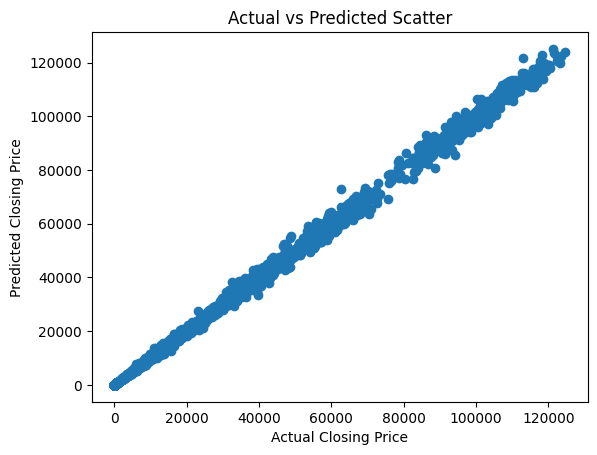

In [41]:
# RMS Error of linear regression model
rmse = np.sqrt(mean_squared_error(y_test2, y_pred2))
print(rmse)

# plotting actual v/s predicted values
plt.scatter(y_test2, y_pred2)
plt.xlabel("Actual Closing Price")
plt.ylabel("Predicted Closing Price")
plt.title("Actual vs Predicted Scatter")
plt.show()

In [42]:
#Importing Coefficients from model to extract into json

# values for scaling
mean = scaler.mean_.tolist()
scale = scaler.scale_.tolist()

# weights for predictin up or down
weights = model.coef_[0].tolist()
bias = model.intercept_[0]

#weights to predict closing price of next day
weights_close = model.coef_[0].tolist()
bias_close = model.intercept_[0]

In [43]:
# Creating Json file
model_params = {
    "weights": weights,
    "bias": bias,
    "mean": mean,
    "scale": scale,
    "weights_close": weights_close,
    "bias_close": bias_close
}

with open("model.json", "w") as f:
    json.dump(model_params, f, indent=4)